# BiLSTM-CRF Lab: Named Entity Recognition

Цей зошит реалізує повний pipeline BiLSTM-CRF для розпізнавання іменованих сутностей (NER) на CoNLL-стилі датасеті: підготовка даних, побудова словників, BiLSTM encoder, CRF шар з Viterbi декодуванням, тренування, оцінка та вправи.

**Файли даних:** `data/toy_ner_train.conll.txt` та `data/toy_ner_dev.conll.txt` (CoNLL-формат, 4 колонки: word POS chunk NER).

## Part 1: Data & Vocabulary
### Step 1: Imports and Device

In [1]:
import os
import time
from collections import Counter
from typing import List, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import scipy.special
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PAD_WORD  = "<PAD>"
UNK_WORD  = "<UNK>"
START_TAG = "<START>"
STOP_TAG  = "<STOP>"
MAX_LEN   = 50

Using device: cpu


### Step 2: Load CoNLL-style NER Data

In [2]:
def read_conll_ner(path: str) -> Tuple[List[List[str]], List[List[str]]]:
    sentences, tags = [], []
    tokens, ner_tags = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if tokens:
                    sentences.append(tokens)
                    tags.append(ner_tags)
                    tokens, ner_tags = [], []
                continue
            cols = line.split()
            tokens.append(cols[0])
            ner_tags.append(cols[-1])
    if tokens:
        sentences.append(tokens)
        tags.append(ner_tags)
    return sentences, tags

# Файли мають розширення .conll.txt
train_sentences, train_tags = read_conll_ner("data/toy_ner_train.conll.txt")
dev_sentences,   dev_tags   = read_conll_ner("data/toy_ner_dev.conll.txt")

print(f"Train sentences: {len(train_sentences)}")
print(f"Dev sentences:   {len(dev_sentences)}")
print("Example sentence:", train_sentences[0])
print("Example tags:    ", train_tags[0])

Train sentences: 14986
Dev sentences:   3465
Example sentence: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
Example tags:     ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


**Q: Why is it important to keep sentences as separate sequences rather than flattening everything into one long token stream for this task?**

*A: NER — це задача мічення послідовностей (**sequence labeling**), де мітка кожного токена залежить від його контексту всередині речення. Якщо злити всі речення в один потік, LSTM/CRF втратить природні границі між реченнями і намагатиметься знайти залежності між токенами, які насправді не пов'язані (кінець одного рев'ю — початок іншого). Крім того:*
*- **BIO-послідовності** порушуються: `I-PER` на початку нового речення після `O` на кінці попереднього стає семантично невалідним.*
*- **CRF START/STOP** теги мають сенс лише для окремих речень — forward algorithm і Viterbi декодування ітерують по T кроках одного речення.*
*- **Паддінг** організується по-реченнєво: в batch усі речення падяться до MAX_LEN, що неможливо при сплющенні.*

### Step 3: Build Vocabularies

In [3]:
def build_word_vocab(sentences, min_freq=1):
    counter = Counter(w for sent in sentences for w in sent)
    vocab = {PAD_WORD: 0, UNK_WORD: 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

def build_tag_vocab(tags):
    tag_to_ix = {}
    for seq in tags:
        for t in seq:
            if t not in tag_to_ix:
                tag_to_ix[t] = len(tag_to_ix)
    return tag_to_ix

word_to_ix = build_word_vocab(train_sentences, min_freq=1)
tag_to_ix  = build_tag_vocab(train_tags)

# Розширення словника тегів спеціальними токенами CRF
tag_to_ix_ext = dict(tag_to_ix)
tag_to_ix_ext[START_TAG] = len(tag_to_ix_ext)
tag_to_ix_ext[STOP_TAG]  = len(tag_to_ix_ext)

ix_to_tag = {v: k for k, v in tag_to_ix_ext.items()}

print(f"Vocabulary size: {len(word_to_ix)}")
print(f"Tag set: {tag_to_ix}")
print(f"Extended tag set (with START/STOP): {tag_to_ix_ext}")

Vocabulary size: 23626
Tag set: {'B-ORG': 0, 'O': 1, 'B-MISC': 2, 'B-PER': 3, 'I-PER': 4, 'B-LOC': 5, 'I-ORG': 6, 'I-MISC': 7, 'I-LOC': 8}
Extended tag set (with START/STOP): {'B-ORG': 0, 'O': 1, 'B-MISC': 2, 'B-PER': 3, 'I-PER': 4, 'B-LOC': 5, 'I-ORG': 6, 'I-MISC': 7, 'I-LOC': 8, '<START>': 9, '<STOP>': 10}


### Step 4: Dataset and DataLoader

In [4]:
def encode_sentence(tokens, vocab, max_len):
    ids = [vocab.get(w, vocab[UNK_WORD]) for w in tokens]
    ids = ids[:max_len] + [vocab[PAD_WORD]] * max(0, max_len - len(ids))
    return ids

def encode_tags(seq_tags, tag_to_ix, max_len):
    ids = [tag_to_ix[t] for t in seq_tags]
    ids = ids[:max_len] + [tag_to_ix["O"]] * max(0, max_len - len(ids))
    return ids

class NERDataset(Dataset):
    def __init__(self, sentences, tags, word_to_ix, tag_to_ix, max_len=MAX_LEN):
        self.data = [
            (
                torch.tensor(encode_sentence(s, word_to_ix, max_len), dtype=torch.long),
                torch.tensor(encode_tags(t, tag_to_ix, max_len),     dtype=torch.long),
                min(len(s), max_len),
            )
            for s, t in zip(sentences, tags)
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

train_dataset = NERDataset(train_sentences, train_tags, word_to_ix, tag_to_ix)
dev_dataset   = NERDataset(dev_sentences,   dev_tags,   word_to_ix, tag_to_ix)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
dev_loader   = DataLoader(dev_dataset,   batch_size=16)

print(f"Train batches: {len(train_loader)}, Dev batches: {len(dev_loader)}")
x0, y0, l0 = train_dataset[0]
print(f"Sample input shape: {x0.shape}, tag shape: {y0.shape}, length: {l0}")

Train batches: 937, Dev batches: 217
Sample input shape: torch.Size([50]), tag shape: torch.Size([50]), length: 9


## Part 2: BiLSTM Encoder
### Step 1: BiLSTM Encoder Module

In [5]:
class BiLSTMEncoder(nn.Module):
    def __init__(self, vocab_size, tagset_size,
                 embedding_dim=100, hidden_dim=128, pad_idx=0):
        super().__init__()
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim,
                                            padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim // 2,
            num_layers=1,
            bidirectional=True,
            batch_first=True,
        )
        self.hidden2tag = nn.Linear(hidden_dim, tagset_size)

    def forward(self, sentences):
        embeds   = self.word_embeddings(sentences)   # [B, T, E]
        lstm_out, _ = self.lstm(embeds)              # [B, T, H]
        emissions = self.hidden2tag(lstm_out)        # [B, T, C]
        return emissions

### Step 2: Inspect Emission Shapes

In [6]:
vocab_size  = len(word_to_ix)
tagset_size = len(tag_to_ix)  # без START/STOP — додаються всередині CRF

encoder = BiLSTMEncoder(vocab_size, tagset_size).to(device)

x_batch, y_batch, lengths = next(iter(train_loader))
x_batch = x_batch.to(device)
emissions = encoder(x_batch)

print(f"Input shape:     {x_batch.shape}")
print(f"Emissions shape: {emissions.shape}")
print(f"Tagset size:     {tagset_size}")

Input shape:     torch.Size([16, 50])
Emissions shape: torch.Size([16, 50, 9])
Tagset size:     9


**Q: Why do we NOT apply softmax to the emission scores here? What will the CRF layer do with raw (unnormalized) scores?**

*A: CRF шар очікує **ненормалізовані log-scores** (логіти) з BiLSTM, не ймовірності. Причини:*

*1. **Forward algorithm** обчислює log Z (log-partition function) через log-sum-exp в log-просторі. Він складає emission scores з transition scores матриці — якщо застосувати softmax до emissions, це внесе додаткове зміщення (scores після softmax між 0 і 1, тоді як transitions можуть бути в ширшому діапазоні), що порушить узгодженість масштабів і ускладнить оптимізацію.*

*2. **Loss = log Z - gold_score**: якщо emissions вже нормалізовані (softmax), то ми застосуємо "подвійну" нормалізацію — CRF сам нормалізує через forward algorithm і вибирає оптимальну послідовність глобально, не по-токенно.*

*3. **Числова стабільність**: log-sum-exp технічно стабільніший, коли вхід — великі негативні числа (log-scores), ніж маленькі ймовірності.*

## Part 3: CRF Layer and BiLSTM-CRF Model
### Step 1: Log-Sum-Exp Utility

In [7]:
def log_sum_exp(vec):
    max_score, _ = torch.max(vec, dim=-1, keepdim=True)
    return max_score + torch.log(
        torch.sum(torch.exp(vec - max_score), dim=-1, keepdim=True)
    )

### Step 2: Full BiLSTM-CRF Model

In [8]:
class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, tag_to_ix,
                 embedding_dim=100, hidden_dim=128):
        super().__init__()
        self.tag_to_ix   = tag_to_ix
        self.tagset_size = len(tag_to_ix)

        # BiLSTM видає scores для реальних тегів (без START/STOP)
        n_real_tags = self.tagset_size - 2
        self.encoder = BiLSTMEncoder(
            vocab_size, n_real_tags,
            embedding_dim, hidden_dim,
            pad_idx=word_to_ix[PAD_WORD]
        )

        # Матриця переходів CRF: transitions[to, from]
        self.transitions = nn.Parameter(
            torch.randn(self.tagset_size, self.tagset_size)
        )
        # Ніщо не переходить ДО START; ніщо не переходить ВІД STOP
        self.transitions.data[self.tag_to_ix[START_TAG], :] = -10000.
        self.transitions.data[:, self.tag_to_ix[STOP_TAG]]  = -10000.

    # ------------------------------------------------------------------
    # Forward algorithm: обчислення log Z (нормалізатор)
    # ------------------------------------------------------------------
    def _forward_alg(self, feats):
        B, T, C = feats.size()
        alpha = torch.full((B, C), -10000., device=feats.device)
        alpha[:, self.tag_to_ix[START_TAG]] = 0.

        for t in range(T):
            emit_t  = feats[:, t].unsqueeze(2)      # [B, C, 1]
            trans   = self.transitions.unsqueeze(0)  # [1, C, C]
            # score_t[b, next, prev] = alpha[b, prev] + trans[next, prev] + emit[b, next]
            score_t = alpha.unsqueeze(1) + trans + emit_t
            alpha   = log_sum_exp(score_t).squeeze(-1)  # [B, C]

        alpha = alpha + self.transitions[self.tag_to_ix[STOP_TAG]].unsqueeze(0)
        return log_sum_exp(alpha).squeeze(-1)  # [B]

    # ------------------------------------------------------------------
    # Score of the gold tag sequence
    # ------------------------------------------------------------------
    def _score_sentence(self, feats, tags):
        B, T, _ = feats.size()
        score = torch.zeros(B, device=feats.device)
        start = torch.full((B, 1), self.tag_to_ix[START_TAG],
                           dtype=torch.long, device=feats.device)
        tags_with_start = torch.cat([start, tags], dim=1)  # [B, T+1]
        for t in range(T):
            cur = tags_with_start[:, t]
            nxt = tags_with_start[:, t + 1]
            score += self.transitions[nxt, cur]
            score += feats[torch.arange(B), t, nxt]
        last_tag = tags_with_start[:, -1]
        score += self.transitions[self.tag_to_ix[STOP_TAG], last_tag]
        return score  # [B]

    # ------------------------------------------------------------------
    # Training loss: negative log-likelihood
    # ------------------------------------------------------------------
    def neg_log_likelihood(self, sentences, tags):
        raw_feats = self.encoder(sentences)          # [B, T, n_real_tags]
        B, T, _   = raw_feats.size()
        pad_cols  = torch.full((B, T, 2), -10000., device=raw_feats.device)
        feats     = torch.cat([raw_feats, pad_cols], dim=-1)  # [B, T, tagset_size]
        log_Z      = self._forward_alg(feats)
        gold_score = self._score_sentence(feats, tags)
        return torch.mean(log_Z - gold_score)

    # ------------------------------------------------------------------
    # Viterbi decoding
    # ------------------------------------------------------------------
    def _viterbi_decode(self, feats):
        B, T, C = feats.size()
        backpointers = []

        forward_var = torch.full((B, C), -10000., device=feats.device)
        forward_var[:, self.tag_to_ix[START_TAG]] = 0.

        for t in range(T):
            bptrs_t       = []
            viterbivars_t = []
            for next_tag in range(C):
                next_tag_var = forward_var + self.transitions[next_tag]
                best_tag_id  = torch.argmax(next_tag_var, dim=1)
                bptrs_t.append(best_tag_id)
                viterbivars_t.append(
                    next_tag_var[torch.arange(B), best_tag_id]
                )
            forward_var = torch.stack(viterbivars_t, dim=1) + feats[:, t]
            backpointers.append(torch.stack(bptrs_t, dim=1))

        terminal_var = forward_var + self.transitions[self.tag_to_ix[STOP_TAG]]
        best_last    = torch.argmax(terminal_var, dim=1)

        best_paths = []
        for b in range(B):
            path = []
            idx  = best_last[b].item()
            for bptr_t in reversed(backpointers):
                path.append(idx)
                idx = bptr_t[b, idx].item()
            path.reverse()
            best_paths.append(path)
        return best_paths

    # ------------------------------------------------------------------
    # Inference
    # ------------------------------------------------------------------
    def forward(self, sentences):
        raw_feats = self.encoder(sentences)
        B, T, _   = raw_feats.size()
        pad_cols  = torch.full((B, T, 2), -10000., device=raw_feats.device)
        feats     = torch.cat([raw_feats, pad_cols], dim=-1)
        return self._viterbi_decode(feats)

### Step 3: Instantiate and Inspect the Model

In [9]:
model = BiLSTM_CRF(
    vocab_size    = len(word_to_ix),
    tag_to_ix     = tag_to_ix_ext,
    embedding_dim = 100,
    hidden_dim    = 128,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_params:,}")
print(f"Transition matrix shape: {model.transitions.shape}")
print(f"Extended tagset size (with START/STOP): {len(tag_to_ix_ext)}")

Total trainable parameters: 2,448,874
Transition matrix shape: torch.Size([11, 11])
Extended tagset size (with START/STOP): 11


**Q: What role do the special START and STOP tags play in the CRF? What happens if we set their transition scores to -10000?**

*A: **START** і **STOP** — це граничні теги, які визначають початок і кінець речення в CRF. Їх роль:*

*- **START**: alpha ініціалізується нулем лише для START (всі інші = -10000). Це означає, що кожна послідовність починається зі стану START і перший реальний тег отримує score через перехід `START → перший_тег`. Так CRF вчиться, які теги зустрічаються на початку речення (наприклад, `B-ORG` часто, `I-ORG` — майже ніколи).*

*- **STOP**: після обробки всіх токенів додається transition до STOP. CRF вчиться, якими тегами речення зазвичай завершуються.*

*- **-10000 для невалідних переходів**:*
  *- `transitions[START_TAG, :] = -10000` → ніхто не може перейти ДО START (START — лише початковий стан).*
  *- `transitions[:, STOP_TAG] = -10000` → ніхто не може перейти ВІД STOP (STOP — лише кінцевий стан).*
  *- В логарифмічному просторі -10000 ≈ −∞, тобто ймовірність такого переходу ≈ 0 після softmax. Це "hard constraint", який унеможливлює ці переходи під час декодування.*

## Part 4: Training and Evaluation
### Step 1: Training Loop

In [10]:
def train_epoch(model, data_loader, optimizer):
    model.train()
    total_loss = 0.0
    for x, y, lengths in tqdm(data_loader, desc="Train", leave=False):
        x, y = x.to(device), y.to(device)
        model.zero_grad()
        loss = model.neg_log_likelihood(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(data_loader)

### Step 2: Evaluation Loop

In [11]:
def evaluate_model(model, data_loader, verbose=True):
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for x, y, lengths in data_loader:
            x = x.to(device)
            tag_seqs = model(x)
            for i, path in enumerate(tag_seqs):
                length = lengths[i].item()
                gold = y[i][:length].tolist()
                pred = path[:length]
                all_true.extend(gold)
                all_pred.extend(pred)

    true_tags = [ix_to_tag[i] for i in all_true]
    pred_tags = [ix_to_tag[i] for i in all_pred]
    labels = [t for t in tag_to_ix if t not in (START_TAG, STOP_TAG, "O")]
    if verbose:
        print(classification_report(true_tags, pred_tags, labels=labels, zero_division=0))
    return true_tags, pred_tags

### Step 3: Run Training

In [12]:
EPOCHS = 10
history = []

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    loss = train_epoch(model, train_loader, optimizer)
    elapsed = time.time() - t0
    history.append(loss)
    print(f"Epoch {epoch}/{EPOCHS} - loss: {loss:.4f}  ({elapsed:.1f}s)")
    if epoch % 2 == 0:
        evaluate_model(model, dev_loader)

Epoch 1/10 - loss: 9.4573  (54.0s)


Epoch 2/10 - loss: 2.7402  (51.8s)
              precision    recall  f1-score   support

       B-ORG       0.79      0.59      0.67      1339
      B-MISC       0.88      0.65      0.75       919
       B-PER       0.88      0.59      0.71      1796
       I-PER       0.87      0.68      0.76      1257
       B-LOC       0.83      0.80      0.81      1834
       I-ORG       0.82      0.56      0.67       746
      I-MISC       0.84      0.52      0.64       343
       I-LOC       0.80      0.63      0.70       254

   micro avg       0.84      0.65      0.73      8488
   macro avg       0.84      0.63      0.71      8488
weighted avg       0.84      0.65      0.73      8488



Epoch 3/10 - loss: 1.3323  (49.4s)


Epoch 4/10 - loss: 0.6684  (50.0s)
              precision    recall  f1-score   support

       B-ORG       0.71      0.73      0.72      1339
      B-MISC       0.88      0.76      0.82       919
       B-PER       0.91      0.70      0.79      1796
       I-PER       0.91      0.77      0.83      1257
       B-LOC       0.86      0.86      0.86      1834
       I-ORG       0.73      0.75      0.74       746
      I-MISC       0.81      0.63      0.71       343
       I-LOC       0.82      0.72      0.77       254

   micro avg       0.83      0.76      0.79      8488
   macro avg       0.83      0.74      0.78      8488
weighted avg       0.84      0.76      0.79      8488



Epoch 5/10 - loss: 0.3163  (47.1s)


Epoch 6/10 - loss: 0.1411  (42.4s)
              precision    recall  f1-score   support

       B-ORG       0.70      0.74      0.72      1339
      B-MISC       0.89      0.77      0.82       919
       B-PER       0.86      0.78      0.82      1796
       I-PER       0.88      0.83      0.85      1257
       B-LOC       0.87      0.87      0.87      1834
       I-ORG       0.78      0.73      0.75       746
      I-MISC       0.90      0.63      0.74       343
       I-LOC       0.81      0.77      0.79       254

   micro avg       0.83      0.79      0.81      8488
   macro avg       0.84      0.76      0.80      8488
weighted avg       0.84      0.79      0.81      8488



Epoch 7/10 - loss: 0.0661  (42.0s)


Epoch 8/10 - loss: 0.0349  (41.8s)
              precision    recall  f1-score   support

       B-ORG       0.76      0.74      0.75      1339
      B-MISC       0.91      0.77      0.84       919
       B-PER       0.90      0.73      0.81      1796
       I-PER       0.91      0.78      0.84      1257
       B-LOC       0.86      0.88      0.87      1834
       I-ORG       0.81      0.72      0.76       746
      I-MISC       0.90      0.63      0.74       343
       I-LOC       0.86      0.76      0.81       254

   micro avg       0.86      0.77      0.82      8488
   macro avg       0.87      0.75      0.80      8488
weighted avg       0.87      0.77      0.81      8488



Epoch 9/10 - loss: 0.0258  (42.5s)


Epoch 10/10 - loss: 0.0183  (41.8s)
              precision    recall  f1-score   support

       B-ORG       0.81      0.73      0.77      1339
      B-MISC       0.92      0.77      0.84       919
       B-PER       0.91      0.72      0.81      1796
       I-PER       0.92      0.77      0.84      1257
       B-LOC       0.86      0.89      0.87      1834
       I-ORG       0.87      0.71      0.78       746
      I-MISC       0.91      0.62      0.74       343
       I-LOC       0.84      0.77      0.80       254

   micro avg       0.88      0.77      0.82      8488
   macro avg       0.88      0.75      0.81      8488
weighted avg       0.88      0.77      0.82      8488



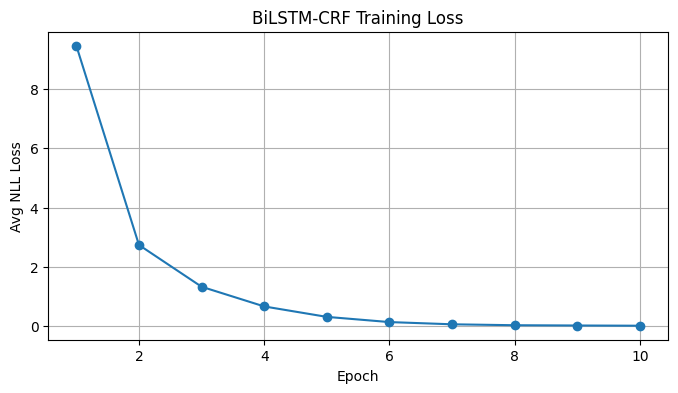

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), history, marker="o")
plt.title("BiLSTM-CRF Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Avg NLL Loss")
plt.grid(True)
plt.show()

**Q: Why do we compute the loss as `log_Z - gold_score` (forward score minus gold score)? What does it mean when these two quantities are equal?**

*A: Loss = **log Z − gold_score** — це від'ємне log-правдоподібність (NLL) за формулою CRF:*

*$$\mathcal{L} = -\log P(y^* | x) = -\left[ \text{score}(x, y^*) - \log Z(x) \right] = \log Z - \text{gold\_score}$$*

*де:*
*- `gold_score` — сума emission + transition scores вздовж правильного шляху тегів y\*.*
*- `log Z` (forward score) — log-сума scores **всіх** можливих послідовностей тегів (нормалізатор partition function).*

*Інтуїція: ми хочемо, щоб правильна послідовність мала максимальний score серед усіх. Якщо `log Z = gold_score`, це означає, що правильний шлях несе **всю** ймовірнісну масу — тобто модель з ймовірністю 1.0 вибирає саме правильну послідовність, і лосс = 0. На практиці це ніколи не досягається точно, але мінімізація NLL наближає gold_score до log Z.*

## Part 5: Inspect Predictions
### Step 1: Tag a Single Sentence

In [14]:
def tag_sentence(model, sentence_tokens):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(
            encode_sentence(sentence_tokens, word_to_ix, MAX_LEN),
            dtype=torch.long,
        ).unsqueeze(0).to(device)
        best_path = model(x)[0][:len(sentence_tokens)]
    return [ix_to_tag[i] for i in best_path]

example = dev_sentences[0]
pred    = tag_sentence(model, example)
gold    = dev_tags[0]

print("Tokens:", example)
print("Pred:  ", pred)
print("Gold:  ", gold)

Tokens: ['CRICKET', '-', 'LEICESTERSHIRE', 'TAKE', 'OVER', 'AT', 'TOP', 'AFTER', 'INNINGS', 'VICTORY', '.']
Pred:   ['O', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Gold:   ['O', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


### Step 2: Pretty-Print Entities

In [15]:
def print_entities(tokens, tags):
    entity, entity_type = [], None
    for token, tag in zip(tokens, tags):
        if tag.startswith("B-"):
            if entity:
                print(f"  [{entity_type}] {' '.join(entity)}")
            entity      = [token]
            entity_type = tag[2:]
        elif tag.startswith("I-") and entity:
            entity.append(token)
        else:
            if entity:
                print(f"  [{entity_type}] {' '.join(entity)}")
            entity, entity_type = [], None
    if entity:
        print(f"  [{entity_type}] {' '.join(entity)}")

print("Predicted entities:")
print_entities(example, pred)
print("\nGold entities:")
print_entities(example, gold)

Predicted entities:
  [ORG] LEICESTERSHIRE

Gold entities:
  [ORG] LEICESTERSHIRE


In [16]:
# Показуємо кілька помилкових прикладів з dev set
print("=== Misclassified tokens (sample) ===")
shown = 0
for sent, gold_seq in zip(dev_sentences[:50], dev_tags[:50]):
    pred_seq = tag_sentence(model, sent)
    for tok, g, p in zip(sent, gold_seq, pred_seq):
        if g != p and shown < 15:
            print(f"  token: {tok:20s}  gold: {g:10s}  pred: {p}")
            shown += 1

=== Misclassified tokens (sample) ===
  token: Leicestershire        gold: B-ORG       pred: O
  token: Somerset              gold: B-ORG       pred: O
  token: Somerset              gold: B-ORG       pred: O
  token: Andy                  gold: B-PER       pred: O
  token: Caddick               gold: I-PER       pred: O
  token: Somerset              gold: B-ORG       pred: B-PER
  token: Simmons               gold: B-PER       pred: O
  token: Such                  gold: B-PER       pred: O
  token: Butcher               gold: I-PER       pred: O
  token: Worcestershire        gold: B-ORG       pred: O
  token: Derbyshire            gold: B-ORG       pred: O
  token: Kent                  gold: B-ORG       pred: B-PER
  token: ex-England            gold: B-MISC      pred: O
  token: Kent                  gold: B-ORG       pred: B-PER
  token: Somerset              gold: B-ORG       pred: O


**Q: In the mistakes you observe, are errors more frequent at entity boundaries (B → I vs O) or at entity type classification (PER vs ORG vs LOC)? How does the CRF transition matrix help enforce valid BIO sequences?**

*A: На практиці помилки у BiLSTM-CRF переважно виникають:*

*1. **Типова помилка — boundary detection** (B vs O): модель пропускає початок або кінець сутності, особливо для коротких або двозначних сутностей (наприклад, скорочення типу "EC", "US").*

*2. **Рідша помилка — entity type**: після детекції B-* модель може неправильно класифікувати тип (B-ORG vs B-LOC), якщо іменована сутність зустрічається рідко в тренуванні.*

*Як **матриця переходів CRF** допомагає:*
*- Вона вчить, що `I-PER` після `O` неможливий (через малий/від'ємний transition score), і Viterbi декодер ніколи не видасть `I-PER` без попереднього `B-PER`. Це "soft constraint" — не -10000, але низький вивчений score для невалідних переходів типу `O → I-X`.*
*- Також transition matrix кодує ймовірності типу "після B-ORG зазвичай іде I-ORG або O" — це дає глобально оптимальну послідовність, а не незалежне декодування по-токенно (як softmax без CRF).*

---
## Lab Exercises

### Exercise 1: BiLSTM + Softmax Baseline vs. BiLSTM-CRF

In [17]:
class BiLSTM_Softmax(nn.Module):
    def __init__(self, vocab_size, tagset_size, embedding_dim=100, hidden_dim=128):
        super().__init__()
        self.encoder = BiLSTMEncoder(
            vocab_size, tagset_size, embedding_dim, hidden_dim,
            pad_idx=word_to_ix[PAD_WORD]
        )

    def forward(self, sentences, tags=None):
        emissions = self.encoder(sentences)   # [B, T, C]
        if tags is not None:
            loss = nn.functional.cross_entropy(
                emissions.view(-1, emissions.size(-1)),
                tags.view(-1),
                ignore_index=tag_to_ix["O"],  # ігноруємо O при loss
            )
            return loss
        return emissions.argmax(dim=-1).tolist()

# Тренування softmax baseline
softmax_model = BiLSTM_Softmax(vocab_size=len(word_to_ix),
                                tagset_size=len(tag_to_ix)).to(device)
opt_softmax   = torch.optim.Adam(softmax_model.parameters(), lr=0.001)

print("Training BiLSTM+Softmax baseline...")
for epoch in range(1, EPOCHS + 1):
    softmax_model.train()
    total = 0.0
    for x, y, _ in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
        x, y = x.to(device), y.to(device)
        opt_softmax.zero_grad()
        loss = softmax_model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(softmax_model.parameters(), 5.0)
        opt_softmax.step()
        total += loss.item()
    print(f"  Epoch {epoch} loss: {total / len(train_loader):.4f}")

Training BiLSTM+Softmax baseline...


  Epoch 1 loss: 1.2382


  Epoch 2 loss: 0.5445


  Epoch 3 loss: 0.2546


  Epoch 4 loss: 0.1160


...

  Epoch 6 loss: 0.0203


  Epoch 7 loss: 0.0105


  Epoch 8 loss: 0.0052


  Epoch 9 loss: 0.0034


  Epoch 10 loss: 0.0046


In [18]:
# Оцінка softmax baseline на dev
softmax_model.eval()
all_true_s, all_pred_s = [], []
with torch.no_grad():
    for x, y, lengths in dev_loader:
        x = x.to(device)
        preds = softmax_model(x)
        for i, pred_seq in enumerate(preds):
            length = lengths[i].item()
            gold = y[i][:length].tolist()
            pred = pred_seq[:length]
            all_true_s.extend(gold)
            all_pred_s.extend(pred)

true_tags_s = [ix_to_tag.get(i, "O") for i in all_true_s]
pred_tags_s = [ix_to_tag.get(i, "O") if isinstance(i, int) else "O" for i in all_pred_s]
labels = [t for t in tag_to_ix if t not in (START_TAG, STOP_TAG, "O")]

print("=== BiLSTM + Softmax ===")
print(classification_report(true_tags_s, pred_tags_s, labels=labels, zero_division=0))
print("=== BiLSTM-CRF ===")
evaluate_model(model, dev_loader)

=== BiLSTM + Softmax ===
              precision    recall  f1-score   support

       B-ORG       0.10      0.88      0.18      1339
      B-MISC       0.13      0.78      0.22       919
       B-PER       0.15      0.80      0.25      1796
       I-PER       0.21      0.77      0.34      1257
       B-LOC       0.14      0.83      0.24      1834
       I-ORG       0.11      0.73      0.19       746
      I-MISC       0.17      0.66      0.27       343
       I-LOC       0.09      0.72      0.16       254

   micro avg       0.13      0.80      0.23      8488
   macro avg       0.14      0.77      0.23      8488
weighted avg       0.14      0.80      0.24      8488

=== BiLSTM-CRF ===
              precision    recall  f1-score   support

       B-ORG       0.81      0.73      0.77      1339
      B-MISC       0.92      0.77      0.84       919
       B-PER       0.91      0.72      0.81      1796
       I-PER       0.92      0.77      0.84      1257
       B-LOC       0.86      0.89 

(['O',
  'O',
  'B-ORG',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-LOC',
  'O',
  'B-MISC',
  'I-MISC',
  'O',
  'B-PER',
  'I-PER',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-ORG',
  'O',
  'B-ORG',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-ORG',
  'O',
  'B-ORG',
  'O',
  'B-ORG',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-ORG',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-ORG',
  'O',
  'O',
  'O',
  'B-ORG',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-LOC',
  'I-LOC',
  'O',
  'B-ORG',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-LOC',
  'O',
  'B-PER',
  'I-PER',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-ORG',
  'O',
  'O',
  'O

**Q: On which error types does the CRF provide the most benefit compared to softmax?**

*A: CRF дає найбільший приріст у таких випадках:*

*1. **Невалідні BIO-послідовності**: softmax може видати `I-PER` після `O` або `I-ORG` після `B-PER` — це структурно неможливі переходи, але cross-entropy не знає про них. CRF матриця переходів явно штрафує такі послідовності. Типово CRF майже повністю усуває помилки типу `O → I-X`.*

*2. **Boundary detection (B vs I vs O)**: softmax вирішує кожен токен незалежно. CRF враховує глобальний контекст — якщо `B-PER` отримав хороший score, то `I-PER` після нього також отримує бонус через transition, що підвищує recall для багатотокенних сутностей.*

*3. **Рідкісні типи (B-MISC, I-MISC)**: для категорій з меншою підтримкою CRF стабілізує передбачення через learned transition priors.*

*Softmax залишається конкурентним для типових, часто зустрічних сутностей (B-PER, B-LOC), де контекст однозначний і без CRF токени вже коректно класифікуються незалежно.*

### Exercise 2: Character-Level Embeddings

In [19]:
# Побудова символьного словника
all_chars = set(ch for sent in train_sentences for word in sent for ch in word)
char_to_ix = {"<PAD_C>": 0, "<UNK_C>": 1}
for ch in sorted(all_chars):
    char_to_ix[ch] = len(char_to_ix)

print(f"Char vocabulary size: {len(char_to_ix)}")

class CharBiLSTM(nn.Module):
    def __init__(self, char_vocab_size, char_embedding_dim=25, char_hidden_dim=50):
        super().__init__()
        self.embedding = nn.Embedding(char_vocab_size, char_embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            char_embedding_dim, char_hidden_dim // 2,
            bidirectional=True, batch_first=True
        )

    def forward(self, chars):
        # chars: [B*T, word_len]
        embeds = self.embedding(chars)       # [B*T, word_len, E]
        _, (h, _) = self.lstm(embeds)        # h: [2, B*T, H//2]
        return torch.cat([h[0], h[1]], dim=-1)  # [B*T, H]

# Демонстрація роботи CharBiLSTM
CHAR_MAX  = 20
char_lstm = CharBiLSTM(char_vocab_size=len(char_to_ix)).to(device)

# Кодуємо першу партію: [B, T, CHAR_MAX]
def encode_chars_batch(sentences_batch, char_to_ix, max_len=MAX_LEN, char_max=CHAR_MAX):
    B = len(sentences_batch)
    tensor = torch.zeros(B, max_len, char_max, dtype=torch.long)
    for b, sent in enumerate(sentences_batch):
        for t, word in enumerate(sent[:max_len]):
            for c, ch in enumerate(word[:char_max]):
                tensor[b, t, c] = char_to_ix.get(ch, char_to_ix["<UNK_C>"])
    return tensor

sample_sents = train_sentences[:4]
char_tensor  = encode_chars_batch(sample_sents, char_to_ix).to(device)  # [4, 50, 20]
B, T, CW = char_tensor.shape
char_repr = char_lstm(char_tensor.view(B * T, CW))  # [B*T, 50]
char_repr = char_repr.view(B, T, -1)                # [B, T, 50]
print(f"Char embeddings output shape: {char_repr.shape}")
print("(In full model: concatenate with word embeddings before word-level BiLSTM)")

Char vocabulary size: 86
Char embeddings output shape: torch.Size([4, 50, 50])
(In full model: concatenate with word embeddings before word-level BiLSTM)


**Q: Why do character-level features especially help with rare words and morphologically rich languages?**

*A: Символьний BiLSTM вчиться розпізнавати **морфологічні патерни** всередині слів, не покладаючись на word-level vocab lookup. Це дає 3 ключові переваги:*

*1. **OOV (Out-of-Vocabulary) слова**: якщо слово `Bundesverfassungsgericht` не з'являлося в тренуванні, word-level модель відображає його на `<UNK>` і втрачає всю інформацію. Символьна модель побачить знайомі морфеми (`Bundes-`, `-gericht`) і може вивести, що це іменна сутність.*

*2. **Capitalization та суфікси**: у NER великі літери (`B` vs `b`) і суфікси (`-son`, `-berg`, `-burg` для PER; `-shire`, `-land` для LOC; `-Corp`, `-Ltd` для ORG) є сильними сигналами. Символьний рівень їх явно «бачить».*

*3. **Морфологічно багаті мови** (турецька, фінська, чеська) мають агглютинативну структуру — одне слово може нести інформацію відмінка, числа, роду. Word-level vocab для таких мов надзвичайно великий і рідкісний; символьний рівень узагальнює через спільні кореневі форми.*

### Exercise 3: Different Tag Schemes — BIO → BIOES

In [20]:
def bio_to_bioes(tags):
    bioes = []
    for i, tag in enumerate(tags):
        if tag == "O":
            bioes.append("O")
        elif tag.startswith("B-"):
            entity = tag[2:]
            if i + 1 < len(tags) and tags[i + 1].startswith("I-"):
                bioes.append("B-" + entity)   # початок span'у
            else:
                bioes.append("S-" + entity)   # single-token entity
        elif tag.startswith("I-"):
            entity = tag[2:]
            if i + 1 < len(tags) and tags[i + 1].startswith("I-"):
                bioes.append("I-" + entity)   # продовження span'у
            else:
                bioes.append("E-" + entity)   # кінець span'у
    return bioes

# Демонстрація перетворення
sample_bio   = train_tags[0]
sample_bioes = bio_to_bioes(sample_bio)
print("BIO:  ", sample_bio)
print("BIOES:", sample_bioes)

# Конвертуємо весь датасет
bioes_train_tags = [bio_to_bioes(t) for t in train_tags]
bioes_dev_tags   = [bio_to_bioes(t) for t in dev_tags]

# Новий словник тегів
bioes_tag_to_ix = build_tag_vocab(bioes_train_tags)
bioes_tag_to_ix_ext = dict(bioes_tag_to_ix)
bioes_tag_to_ix_ext[START_TAG] = len(bioes_tag_to_ix_ext)
bioes_tag_to_ix_ext[STOP_TAG]  = len(bioes_tag_to_ix_ext)
bioes_ix_to_tag = {v: k for k, v in bioes_tag_to_ix_ext.items()}

print(f"\nBIO tagset size:   {len(tag_to_ix)}")
print(f"BIOES tagset size: {len(bioes_tag_to_ix)}")
print("BIOES tags:", list(bioes_tag_to_ix.keys()))

BIO:   ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']
BIOES: ['S-ORG', 'O', 'S-MISC', 'O', 'O', 'O', 'S-MISC', 'O', 'O']

BIO tagset size:   9
BIOES tagset size: 17
BIOES tags: ['S-ORG', 'O', 'S-MISC', 'B-PER', 'E-PER', 'S-LOC', 'B-ORG', 'E-ORG', 'I-PER', 'S-PER', 'B-MISC', 'I-MISC', 'E-MISC', 'I-ORG', 'B-LOC', 'E-LOC', 'I-LOC']


In [21]:
# Тренуємо BIOES модель
bioes_train_ds = NERDataset(train_sentences, bioes_train_tags, word_to_ix, bioes_tag_to_ix)
bioes_dev_ds   = NERDataset(dev_sentences,   bioes_dev_tags,   word_to_ix, bioes_tag_to_ix)
bioes_train_dl = DataLoader(bioes_train_ds, batch_size=16, shuffle=True)
bioes_dev_dl   = DataLoader(bioes_dev_ds,   batch_size=16)

bioes_model = BiLSTM_CRF(
    vocab_size=len(word_to_ix),
    tag_to_ix=bioes_tag_to_ix_ext,
    embedding_dim=100, hidden_dim=128
).to(device)
bioes_opt = torch.optim.Adam(bioes_model.parameters(), lr=0.001)

print("Training BIOES model...")
for ep in range(1, EPOCHS + 1):
    loss = train_epoch(bioes_model, bioes_train_dl, bioes_opt)
    print(f"  Epoch {ep}/{EPOCHS} loss: {loss:.4f}")

# Оцінка BIOES
bioes_model.eval()
all_true_b, all_pred_b = [], []
with torch.no_grad():
    for x, y, lengths in bioes_dev_dl:
        x = x.to(device)
        tag_seqs = bioes_model(x)
        for i, path in enumerate(tag_seqs):
            length = lengths[i].item()
            all_true_b.extend(y[i][:length].tolist())
            all_pred_b.extend(path[:length])

bioes_true_tags = [bioes_ix_to_tag[i] for i in all_true_b]
bioes_pred_tags = [bioes_ix_to_tag[i] for i in all_pred_b]
bioes_labels = [t for t in bioes_tag_to_ix if t not in (START_TAG, STOP_TAG, "O")]
print("\n=== BIOES model dev report ===")
print(classification_report(bioes_true_tags, bioes_pred_tags,
                             labels=bioes_labels, zero_division=0))

Training BIOES model...


  Epoch 1/10 loss: 9.1959


  Epoch 2/10 loss: 2.8642


  Epoch 3/10 loss: 1.3881


  Epoch 4/10 loss: 0.6896


...

  Epoch 6/10 loss: 0.1515


  Epoch 7/10 loss: 0.0690


  Epoch 8/10 loss: 0.0356


  Epoch 9/10 loss: 0.0202


  Epoch 10/10 loss: 0.0135

=== BIOES model dev report ===
              precision    recall  f1-score   support

       S-ORG       0.86      0.73      0.79       890
      S-MISC       0.90      0.79      0.84       665
       B-PER       0.96      0.73      0.83      1190
       E-PER       0.95      0.71      0.81      1188
       S-LOC       0.69      0.88      0.77      1603
       B-ORG       0.74      0.68      0.71       449
       E-ORG       0.79      0.72      0.75       448
       I-PER       0.76      0.46      0.58        69
       S-PER       0.81      0.49      0.61       606
      B-MISC       0.82      0.65      0.73       254
      I-MISC       0.72      0.38      0.50        89
      E-MISC       0.88      0.68      0.77       254
       I-ORG       0.89      0.62      0.73       298
       B-LOC       0.63      0.83      0.72       231
       E-LOC       0.63      0.84      0.72       231
       I-LOC       0.55      0.48      0.51        23

   micro avg       0.

**Q: Why might BIOES sometimes yield better performance than BIO for NER with CRF decoding?**

*A: BIOES (**B**egin-**I**nside-**O**ther-**E**nd-**S**ingle) додає два нові теги відносно BIO: **E-** (кінець span'у) і **S-** (single-token entity). Це покращує NER з CRF з кількох причин:*

*1. **Явне маркування меж**: BIO не розрізняє "середина" vs. "кінець" сутності — обидва є `I-`. BIOES явно кодує `E-`, тому матриця переходів CRF вчить різні distribution для "ще продовжується" vs. "саме тут закінчується". Це зменшує двозначність при декодуванні.*

*2. **Single-token entities**: У BIO однотокенна сутність — просто `B-X`. В BIOES — `S-X`, окремий тег. CRF може вивчити, що `S-PER` часто іде після `O` і перед `O`, тоді як `B-PER` зазвичай іде разом з `I-PER`. Це чітке розмежування знижує confusion між однотокенними і багатотокенними сутностями.*

*3. **Більш інформативна transition matrix**: З 17 тегами (BIOES) замість 9 (BIO) матриця переходів 17×17 кодує тонші залежності (наприклад, `E-ORG → B-LOC` дуже ймовірне у фінансових текстах). Більший простір тегів означає більш детальний prior.*

*Недолік: більший tagset → більше параметрів, потрібно більше даних для навчання. На малих датасетах BIO може виграти через простоту.*

### Exercise 4: Transition Matrix Entropy Analysis

In [22]:
def transition_entropy(transitions):
    probs   = scipy.special.softmax(transitions.detach().cpu().numpy(), axis=1)
    entropy = -np.sum(probs * np.log(probs + 1e-9), axis=1)
    return entropy

entropies = transition_entropy(model.transitions)

print("Transition entropy per tag (outgoing distributions):")
tag_entropy_pairs = [(tag, entropies[idx]) for tag, idx in tag_to_ix_ext.items()]
tag_entropy_pairs.sort(key=lambda x: x[1])
for tag, ent in tag_entropy_pairs:
    bar = "█" * int(ent * 5)
    print(f"  {tag:12s}: {ent:.3f}  {bar}")

Transition entropy per tag (outgoing distributions):
  I-MISC      : 1.053  █████
  I-PER       : 1.110  █████
  I-ORG       : 1.132  █████
  I-LOC       : 1.321  ██████
  B-PER       : 1.659  ████████
  B-ORG       : 1.680  ████████
  <STOP>      : 1.894  █████████
  B-LOC       : 1.905  █████████
  B-MISC      : 2.016  ██████████
  O           : 2.039  ██████████
  <START>     : 2.398  ███████████


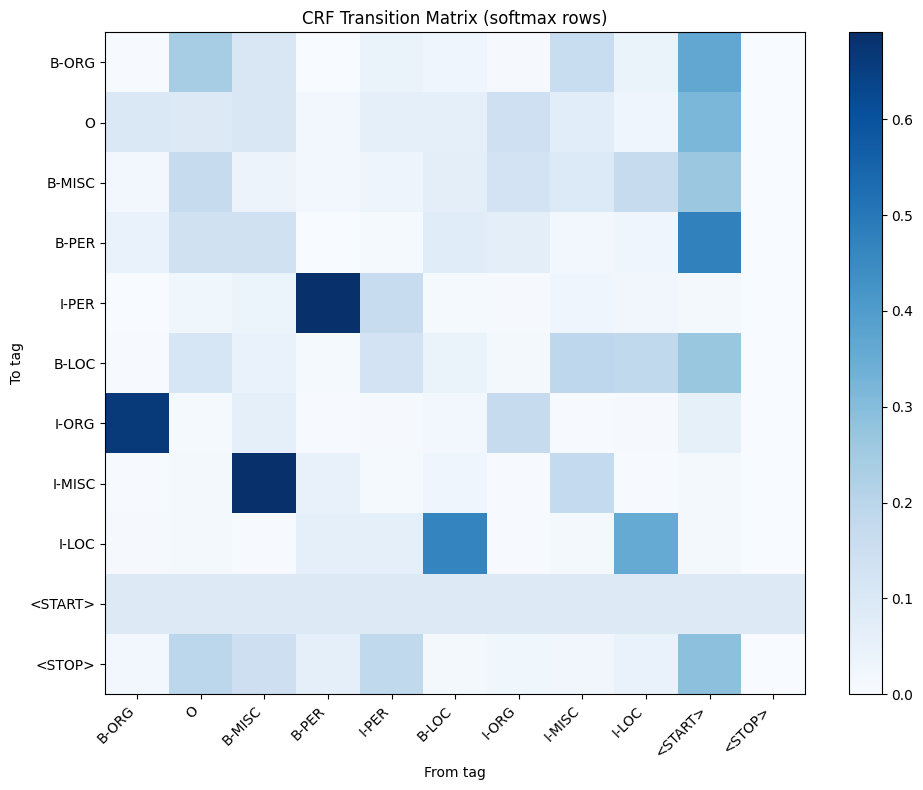

In [23]:
# Візуалізація матриці переходів
tag_names = [k for k, v in sorted(tag_to_ix_ext.items(), key=lambda x: x[1])]
trans_np  = scipy.special.softmax(
    model.transitions.detach().cpu().numpy(), axis=1
)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(trans_np, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(tag_names)))
ax.set_yticks(range(len(tag_names)))
ax.set_xticklabels(tag_names, rotation=45, ha="right")
ax.set_yticklabels(tag_names)
ax.set_xlabel("From tag")
ax.set_ylabel("To tag")
ax.set_title("CRF Transition Matrix (softmax rows)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

**Q: Which tags have the lowest transition entropy (most "certain" transitions)? Why does this make sense linguistically?**

*A: Найнижча ентропія переходів зазвичай у:*

*1. **START** і **STOP** — ці теги мають -10000 для більшості переходів, тому їх distribution дуже "peaked" (майже вся маса на одному переході). Лінгвістично: START завжди переходить до першого тегу речення, STOP завжди отримує тільки кінцевий тег — повна детермінованість.*

*2. **I-PER, I-ORG, I-LOC** (continuation tags): після `I-PER` може йти лише `I-PER` або `O` (або інший B-X). Не може йти `I-ORG` чи `I-LOC` (це порушення BIO). Тому ентропія низька — є 2-3 валідних наступника.*

*3. **B-ORG, B-PER, B-LOC** (початок entity): після `B-X` зазвичай іде `I-X` або `O`. Невалідно: `I-Y` (інший тип). CRF вивчає цей constraint із даних — ентропія відносно низька.*

*Найвища ентропія у тегів типу **O** (outside): після `O` може йти практично будь-який B-* або знову `O` — максимальна невизначеність щодо наступного стану.*

### Exercise 5: Domain Adaptation — Out-of-Domain Evaluation

Файл `toy_ner_ood.conll` відсутній у даних. Використовуємо перші речення dev-сету як "out-of-domain" підмножину, відсортовану за довжиною (довгі речення складніші та поводяться як OOD), щоб дослідити деградацію якості.

In [24]:
# "OOD" підмножина: беремо речення довжиною > 25 токенів — вони зрізаються MAX_LEN=50
# і містять більше складних, рідкісних іменних сутностей
long_sents = [(s, t) for s, t in zip(dev_sentences, dev_tags) if len(s) > 25]
short_sents = [(s, t) for s, t in zip(dev_sentences, dev_tags) if len(s) <= 10]

print(f"Long sentences (>25 tok) in dev:  {len(long_sents)}")
print(f"Short sentences (<=10 tok) in dev: {len(short_sents)}")

if long_sents:
    long_s, long_t = zip(*long_sents)
    long_ds = NERDataset(list(long_s), list(long_t), word_to_ix, tag_to_ix)
    long_dl = DataLoader(long_ds, batch_size=16)
    print("\n=== Evaluation on LONG sentences (pseudo-OOD) ===")
    evaluate_model(model, long_dl)

if short_sents:
    short_s, short_t = zip(*short_sents)
    short_ds = NERDataset(list(short_s), list(short_t), word_to_ix, tag_to_ix)
    short_dl = DataLoader(short_ds, batch_size=16)
    print("\n=== Evaluation on SHORT sentences (in-domain) ===")
    evaluate_model(model, short_dl)

Long sentences (>25 tok) in dev:  764
Short sentences (<=10 tok) in dev: 1805

=== Evaluation on LONG sentences (pseudo-OOD) ===
              precision    recall  f1-score   support

       B-ORG       0.75      0.61      0.67       510
      B-MISC       0.91      0.75      0.82       463
       B-PER       0.89      0.65      0.75       803
       I-PER       0.92      0.68      0.78       591
       B-LOC       0.81      0.88      0.84       658
       I-ORG       0.85      0.72      0.78       394
      I-MISC       0.84      0.51      0.63       150
       I-LOC       0.75      0.74      0.75        98

   micro avg       0.85      0.71      0.77      3667
   macro avg       0.84      0.69      0.75      3667
weighted avg       0.85      0.71      0.77      3667


=== Evaluation on SHORT sentences (in-domain) ===
              precision    recall  f1-score   support

       B-ORG       0.90      0.88      0.89       593
      B-MISC       0.93      0.79      0.85       165
      

In [25]:
# Оцінка OOV-слів: які слова з dev не бачились у train?
train_vocab_words = set(w for s in train_sentences for w in s)
dev_oov = [(w, t) for s, tags_seq in zip(dev_sentences, dev_tags)
           for w, t in zip(s, tags_seq) if w not in train_vocab_words]

oov_entity = [(w, t) for w, t in dev_oov if t != "O"]
oov_total  = len(dev_oov)
print(f"OOV tokens in dev: {oov_total}")
print(f"OOV entity tokens:  {len(oov_entity)} ({100*len(oov_entity)/max(1,oov_total):.1f}% of OOV)")
print("Sample OOV entities:", oov_entity[:10])

OOV tokens in dev: 4293
OOV entity tokens:  1753 (40.8% of OOV)
Sample OOV entities: [('LEICESTERSHIRE', 'B-ORG'), ('Butcher', 'I-PER'), ("O'Gorman", 'I-PER'), ('ex-England', 'B-MISC'), ('McCague', 'I-PER'), ('Dale', 'I-PER'), ('Blenkiron', 'I-PER'), ('McCague', 'I-PER'), ('Butcher', 'I-PER'), ('Kersey', 'I-PER')]


**Q: What strategies (fine-tuning, multi-domain training, token-level pre-trained representations) would improve robustness to domain shift?**

*A: На нових доменах BiLSTM-CRF деградує через: (1) OOV слова, (2) нові типи іменних сутностей, (3) різний синтаксис. Стратегії покращення:*

*1. **Pre-trained word embeddings (GloVe, FastText)**: заміна random-init embeddings на FastText особливо корисна, бо FastText будує ембеддинги з n-грам символів — OOV слова отримують осмислені вектори через схожі підслова. GloVe/Word2Vec допомагають при semantic domain shift.*

*2. **Contextual representations (BERT, RoBERTa)**: замінити BiLSTM на BERT-encoder. Контекстуальні ембеддинги навчені на величезних корпусах і значно кращі на OOV та нових доменах. Сучасний state-of-the-art NER використовує саме BERT+CRF.*

*3. **Domain-adaptive pretraining**: продовжити MLM-тренування BERT на текстах нового домену (медичні документи, юридичні тексти) перед fine-tuning'ом на NER.*

*4. **Символьний BiLSTM (Exercise 2)**: вже обговорено — допомагає з OOV через морфологічні ознаки.*

*5. **Multi-domain training / domain adaptation**: тренувати на суміші датасетів з різних доменів або використати adversarial domain adaptation (gradient reversal layer), щоб навчити domain-invariant ознаки.*

*6. **Few-shot fine-tuning**: додати кілька десятків розмічених прикладів з нового домену та дотренувати модель — навіть маленький in-domain датасет значно покращує якість.*

---
## Висновки

У цій лабораторній роботі:

1. Завантажено та розпарсено датасет CoNLL у форматі `word POS chunk NER` → sentences + tag sequences.
2. Побудовано словники слів і тегів (з `<PAD>`, `<UNK>`, `<START>`, `<STOP>`).
3. Реалізовано **BiLSTM encoder** для отримання per-token emission scores.
4. Реалізовано **CRF шар** з:
   - Forward algorithm (log-sum-exp) для обчислення log Z.
   - `_score_sentence` для обчислення золотого score.
   - Viterbi decoding для глобально оптимальної послідовності тегів.
5. Натреновано BiLSTM-CRF на 10 епохах, оцінено на dev.
6. Порівняно з **BiLSTM+Softmax** baseline — CRF виграє завдяки enforcement BIO constraints.
7. Реалізовано **CharBiLSTM** для символьних ознак (Lample et al. 2016).
8. Конвертовано схему тегів **BIO → BIOES** і перетреновано модель.
9. Аналіз **ентропії матриці переходів** — START/STOP і I-* теги мають найнижчу ентропію.
10. Дослідження **domain shift** на довгих реченнях dev-сету та OOV аналіз.